In [1]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np
import sklearn
from sklearn.neighbors import KNeighborsClassifier
from sklearn.utils import shuffle 
from sklearn.linear_model import LinearRegression, LogisticRegression, Lasso, LassoCV
from sklearn import metrics
from sys import platform
import scipy as sp
import scipy.io
from scipy.stats import pearsonr
import os
from random import randrange
from itertools import combinations
import random
from statsmodels.stats.multitest import fdrcorrection

In [2]:
# Phase 1: load individual connectivity matrices, create group similarity matrices, calculate success rate and chance level

In [3]:
# load individual mats, take lower triangle without diagonal, concatenate all subs together to create group matrices per timepoint
def mat2vec(datadir,subs,length):
    mats=[x for x in os.listdir(datadir) if x[:length] in subs]
    mats.sort()
    size_mat=scipy.io.loadmat(datadir + '/' + mats[1])
    a=list(size_mat.keys())
    size_mat=size_mat[a[3]]
    i=0
    dim=np.shape(size_mat)
    N=len(mats)
    bigmat=np.zeros([int((dim[0]*(dim[0]-1))/2),N])
    for file in mats:
        # print(file)
        submat=scipy.io.loadmat(datadir + '/' + file)
        b=list(submat.keys())
        submat=submat[b[3]]
        bigmat[:,i]=submat[np.tril_indices(dim[1], k = -1)]
        i+=1
    return bigmat

In [4]:
# create similarity matrices for two timepoints 
def create_cor_mat2(X,Y):
    sub_cor=np.corrcoef(X.T, Y.T)[:np.shape(X)[1], np.shape(X)[1]:]
    sub_cor=pd.DataFrame(sub_cor.T)
    return sub_cor

In [5]:
# calculate success: is diagonal value the highest value in the row
def calc_success(sub_cor):
    counter = 0
    for t in range(0,np.shape(sub_cor)[1]):
        val = sub_cor.loc[t,t]
        max_val=max(sub_cor.loc[:,t])
        if max_val==val:
            counter+=1
    success_rate=counter/(np.shape(sub_cor)[1])
    return counter,success_rate

In [6]:
# Calculate chance rate
def perm(sub_cor, K):
    perm_success_rate=[]
    for i in range(K):
        shuffled_cor_mat=sub_cor.sample(frac=1).reset_index(drop=True)
        shuffled_counter,shuffled_sucess_rate=calc_success(shuffled_cor_mat)
        perm_success_rate.append(shuffled_sucess_rate)
    chance_level=np.mean(perm_success_rate)
    return chance_level, perm_success_rate

In [7]:
# Soldiers

In [8]:
rootdir1=('/Volumes/homes/Noga/full_data/Results/T1')
subs1=[x for x in os.listdir(rootdir1) if len(x)==4]
rootdir2=('/Volumes/homes/Noga/full_data/Results/T2')
subs2=[x for x in os.listdir(rootdir2) if len(x)==4]
rootdir3=('/Volumes/homes/Noga/full_data/Results/T3')
subs3=[x for x in os.listdir(rootdir3) if len(x)==4]
rootdir4=('/Volumes/homes/Noga/full_data/Results/T4')
subs4=[x for x in os.listdir(rootdir4) if len(x)==4]
subs4=np.intersect1d(subs1,subs4)

subs=np.intersect1d(np.intersect1d(np.intersect1d(subs1,subs4),subs2),subs3)
atlas='Schaefer1000'

In [9]:
subs1.sort()
subs2.sort()
subs3.sort()
subs4.sort()
subs.sort()

In [10]:
mat1=mat2vec('/Volumes/homes/Noga/full_data/Results/Atlas_CMs/T1/' + atlas,subs2,4)
mat2=mat2vec('/Volumes/homes/Noga/full_data/Results/Atlas_CMs/T2/' + atlas,subs2,4)
sub_cor12=create_cor_mat2(mat1,mat2)
counter12,success_rate12 = calc_success(sub_cor12)
chance_level12, perm_success_rate12=perm(sub_cor12, 10)
print('Number of Participants: %s\nSucessful Fingerprinting: %s\nSuccess Rate: %s\nChance-Level Success rate: %s' % (np.shape(sub_cor12)[1],counter12,success_rate12,chance_level12))

Number of Participants: 45
Sucessful Fingerprinting: 36
Success Rate: 0.8
Chance-Level Success rate: 0.03777777777777778


In [11]:
mat1=mat2vec('/Volumes/homes/Noga/full_data/Results/Atlas_CMs/T1/' + atlas,subs3,4)
mat3=mat2vec('/Volumes/homes/Noga/full_data/Results/Atlas_CMs/T3/' + atlas,subs3,4)
sub_cor13=create_cor_mat2(mat1,mat3)
counter13,success_rate13 = calc_success(sub_cor13)
chance_level13, perm_success_rate13=perm(sub_cor13, 10)
print('Number of Participants: %s\nSucessful Fingerprinting: %s\nSuccess Rate: %s\nChance-Level Success rate: %s' % (np.shape(sub_cor13)[1],counter13,success_rate13,chance_level13))

Number of Participants: 43
Sucessful Fingerprinting: 40
Success Rate: 0.9302325581395349
Chance-Level Success rate: 0.02558139534883721


In [12]:
mat1=mat2vec('/Volumes/homes/Noga/full_data/Results/Atlas_CMs/T1/' + atlas,subs4,4)
mat4=mat2vec('/Volumes/homes/Noga/full_data/Results/Atlas_CMs/T4/' + atlas,subs4,4)
sub_cor14=create_cor_mat2(mat1,mat4)
counter14,success_rate14 = calc_success(sub_cor14)
chance_level14, perm_success_rate14=perm(sub_cor14, 10)
print('Number of Participants: %s\nSucessful Fingerprinting: %s\nSuccess Rate: %s\nChance-Level Success rate: %s' % (np.shape(sub_cor14)[1],counter14,success_rate14,chance_level14))

Number of Participants: 41
Sucessful Fingerprinting: 39
Success Rate: 0.9512195121951219
Chance-Level Success rate: 0.02682926829268293


In [13]:
# Controls

In [ ]:
rootdir1_con=('/Volumes/homes/Noga/full_data/Results/Control/T1')
subs1_con=[x for x in os.listdir(rootdir1_con) if len(x)==3]
rootdir2_con=('/Volumes/homes/Noga/full_data/Results/Control/T2')
subs2_con=[x for x in os.listdir(rootdir2_con) if len(x)==3] # and x!='133']
rootdir3_con=('/Volumes/homes/Noga/full_data/Results/Control/T3')
subs3_con=[x for x in os.listdir(rootdir3_con) if len(x)==3]
rootdir4_con=('/Volumes/homes/Noga/full_data/Results/Control/T4')
subs4_con=[x for x in os.listdir(rootdir4_con) if len(x)==3]
 
subs_con=np.intersect1d(np.intersect1d(subs1_con,subs2_con),subs3_con)

In [15]:
subs1_con.sort()
subs2_con.sort()
subs3_con.sort()
subs4_con.sort()
subs_con.sort()

In [16]:
mat1_con=mat2vec('/Volumes/homes/Noga/full_data/Results/Atlas_CMs/Control/T1/' + atlas,subs2_con,3)
mat2_con=mat2vec('/Volumes/homes/Noga/full_data/Results/Atlas_CMs/Control/T2/' + atlas,subs2_con,3)
sub_cor12_con=create_cor_mat2(mat1_con,mat2_con)
counter12_con,success_rate12_con = calc_success(sub_cor12_con)
chance_level12_con, perm_success_rate12_con=perm(sub_cor12_con, 10)
print('Number of Participants: %s\nSucessful Fingerprinting: %s\nSuccess Rate: %s\nChance-Level Success rate: %s' % (np.shape(sub_cor12_con)[1],counter12_con,success_rate12_con,chance_level12_con))

Number of Participants: 37
Sucessful Fingerprinting: 36
Success Rate: 0.972972972972973
Chance-Level Success rate: 0.03513513513513514


In [17]:
mat1_con=mat2vec('/Volumes/homes/Noga/full_data/Results/Atlas_CMs/Control/T1/' + atlas,subs3_con,3)
mat3_con=mat2vec('/Volumes/homes/Noga/full_data/Results/Atlas_CMs/Control/T3/' + atlas,subs3_con,3)
sub_cor13_con=create_cor_mat2(mat1_con,mat3_con)
counter13_con,success_rate13_con = calc_success(sub_cor13_con)
chance_level13_con, perm_success_rate13_con=perm(sub_cor13_con, 1000)
print('Number of Participants: %s\nSucessful Fingerprinting: %s\nSuccess Rate: %s\nChance-Level Success rate: %s' % (np.shape(sub_cor13_con)[1],counter13_con,success_rate13_con,chance_level13_con))

Number of Participants: 35
Sucessful Fingerprinting: 34
Success Rate: 0.9714285714285714
Chance-Level Success rate: 0.028342857142857145


In [18]:
mat1_con=mat2vec('/Volumes/homes/Noga/full_data/Results/Atlas_CMs/Control/T1/' + atlas,subs4_con,3)
mat4_con=mat2vec('/Volumes/homes/Noga/full_data/Results/Atlas_CMs/Control/T4/' + atlas,subs4_con,3)
sub_cor14_con=create_cor_mat2(mat1_con,mat4_con)
counter14_con,success_rate14_con = calc_success(sub_cor14_con)
chance_level14_con, perm_success_rate14_con=perm(sub_cor14_con, 10)
print('Number of Participants: %s\nSucessful Fingerprinting: %s\nSuccess Rate: %s\nChance-Level Success rate: %s' % (np.shape(sub_cor14_con)[1],counter14_con,success_rate14_con,chance_level14_con))

Number of Participants: 14
Sucessful Fingerprinting: 12
Success Rate: 0.8571428571428571
Chance-Level Success rate: 0.05


In [19]:
# Phase 2: Network Feature Importance (AKA network contribution score)

In [20]:
parcel_id=pd.read_excel('/Volumes/homes/Noga/Atlases/schaefer_parcellation/scf1000_to_yeo.xlsx')
parcel_id
atlas='Schaefer1000'
networks=np.unique(parcel_id['Network'])

In [21]:
def mat2vec_drop_multiple_networks(datadir,subs,length,networks):
    mats=[x for x in os.listdir(datadir) if x[:length] in subs]
    mats.sort()
    N=len(mats)
    bigmat=pd.DataFrame()

    network_index = parcel_id['Parcel_ID'].loc[parcel_id['Network'].isin(networks)]
    network_index=network_index-1
    for i, file in enumerate(mats):
        submat=scipy.io.loadmat(datadir + '/' + file)
        b=list(submat.keys())
        submat=submat[b[3]]
        submat=pd.DataFrame(submat)
        filtered_submat = submat.drop(network_index, axis=0)
        filtered_submat = filtered_submat.drop(network_index, axis=1)    
        dim=np.shape(filtered_submat)
        filtered_submat=np.array(filtered_submat)
        bigmat.loc[:,i]=filtered_submat[np.tril_indices(dim[1], k = -1)]

    bigmat=np.array(bigmat)
    return bigmat

In [179]:
# Create a dictionary to store the success rates for each network for each iteration
network_iteration_success_without = {network: [] for network in networks}
network_iteration_success_with = {network: [] for network in networks}

# Iterate over all combinations of the networks
for r in range(1, len(networks)):
    for combo in combinations(networks, r):
        # Generate matrices and calculate success rates for the current combination
        mat1 = mat2vec_drop_multiple_networks('/Volumes/homes/Noga/full_data/Results/Atlas_CMs/T1/' + atlas, subs, 4, combo)
        mat2 = mat2vec_drop_multiple_networks ('/Volumes/homes/Noga/full_data/Results/Atlas_CMs/T2/' + atlas, subs, 4, combo)
        sub_cor = create_cor_mat2(mat1, mat2)
        counter, success_rate = calc_success(sub_cor)
        
       # Update network_iteration_success dictionary based on the current combination
        for network in networks:
            if network not in combo:
                network_iteration_success_without[network].append(success_rate)

        for network in networks:
            if network in combo:
                network_iteration_success_with[network].append(success_rate)


average_success_rates_without = {}
for network, success_rates in network_iteration_success_without.items():
    average_success_rates_without[network] = sum(success_rates) / len(success_rates)

average_success_rates_with = {}
for network, success_rates in network_iteration_success_with.items():
    average_success_rates_with[network] = sum(success_rates) / len(success_rates)

# Now average_success_rates dictionary contains the average success rate for each network
print(average_success_rates_without)
print(average_success_rates_with)


In [37]:
# Create a dictionary to store the success rates for each network for each iteration
network_iteration_success_without = {network: [] for network in networks}
network_iteration_success_with = {network: [] for network in networks}

# Iterate over all combinations of the networks
for r in range(1, len(networks)):
    for combo in combinations(networks, r):
        # Generate matrices and calculate success rates for the current combination
        mat1 = mat2vec_drop_multiple_networks('/Volumes/homes/Noga/full_data/Results/Atlas_CMs/T1/' + atlas, subs, 4, combo)
        mat2 = mat2vec_drop_multiple_networks ('/Volumes/homes/Noga/full_data/Results/Atlas_CMs/T3/' + atlas, subs, 4, combo)
        sub_cor = create_cor_mat2(mat1, mat2)
        counter, success_rate = calc_success(sub_cor)
        
        # Update network_iteration_success dictionary based on the current combination
        for network in networks:
            if network not in combo:
                network_iteration_success_without[network].append(success_rate)

        for network in networks:
            if network in combo:
                network_iteration_success_with[network].append(success_rate)


average_success_rates_without = {}
for network, success_rates in network_iteration_success_without.items():
    average_success_rates_without[network] = sum(success_rates) / len(success_rates)

average_success_rates_with = {}
for network, success_rates in network_iteration_success_with.items():
    average_success_rates_with[network] = sum(success_rates) / len(success_rates)

# Now average_success_rates dictionary contains the average success rate for each network
print(average_success_rates_without)
print(average_success_rates_with)


{'Cont': 0.9198966408268742, 'Default': 0.888519748984866, 'DorsAttn': 0.9084533038021417, 'Limbic': 0.8571428571428578, 'SalVentAttn': 0.882613510520488, 'SomMot': 0.859726836471023, 'Vis': 0.8652639350313773}
{'Cont': 0.8335179032853455, 'Default': 0.8648947951273538, 'DorsAttn': 0.8449612403100779, 'Limbic': 0.8962716869693618, 'SalVentAttn': 0.8708010335917316, 'SomMot': 0.8936877076411966, 'Vis': 0.8881506090808421}


In [38]:
# Create a dictionary to store the success rates for each network for each iteration
network_iteration_success_without = {network: [] for network in networks}
network_iteration_success_with = {network: [] for network in networks}

# Iterate over all combinations of the networks
for r in range(1, len(networks)):
    for combo in combinations(networks, r):
        # Generate matrices and calculate success rates for the current combination
        mat1 = mat2vec_drop_multiple_networks('/Volumes/homes/Noga/full_data/Results/Atlas_CMs/T1/' + atlas, subs, 4, combo)
        mat2 = mat2vec_drop_multiple_networks ('/Volumes/homes/Noga/full_data/Results/Atlas_CMs/T4/' + atlas, subs, 4, combo)
        sub_cor = create_cor_mat2(mat1, mat2)
        counter, success_rate = calc_success(sub_cor)
        
        # Update network_iteration_success dictionary based on the current combination
        for network in networks:
            if network not in combo:
                network_iteration_success_without[network].append(success_rate)

        for network in networks:
            if network in combo:
                network_iteration_success_with[network].append(success_rate)


average_success_rates_without = {}
for network, success_rates in network_iteration_success_without.items():
    average_success_rates_without[network] = sum(success_rates) / len(success_rates)

average_success_rates_with = {}
for network, success_rates in network_iteration_success_with.items():
    average_success_rates_with[network] = sum(success_rates) / len(success_rates)

# Now average_success_rates dictionary contains the average success rate for each network
print(average_success_rates_without)
print(average_success_rates_with)


{'Cont': 0.9163763066202094, 'Default': 0.882694541231127, 'DorsAttn': 0.9194734804490905, 'Limbic': 0.867208672086721, 'SalVentAttn': 0.9032133178474644, 'SomMot': 0.845141308555943, 'Vis': 0.8807588075880762}
{'Cont': 0.8459156020131631, 'Default': 0.8795973674022455, 'DorsAttn': 0.842818428184282, 'Limbic': 0.8950832365466515, 'SalVentAttn': 0.8590785907859081, 'SomMot': 0.9171506000774294, 'Vis': 0.8815331010452965}


In [23]:
# Controls
rootdir1=('/Volumes/homes/Noga/full_data/Results/Control/T1/')
cons1=[x for x in os.listdir(rootdir1) if len(x)==3]
rootdir2=('/Volumes/homes/Noga/full_data/Results/Control/T2')
cons2=[x for x in os.listdir(rootdir2) if len(x)==3]
rootdir3=('/Volumes/homes/Noga/full_data/Results/Control/T3')
cons3=[x for x in os.listdir(rootdir3) if len(x)==3]
rootdir4=('/Volumes/homes/Noga/full_data/Results/Control/T4')
cons4=['102','104','105','107','108','113','114','119','122','125','127','129','136','139']

cons=np.intersect1d(np.intersect1d(cons1,cons2),cons3)

In [24]:
cons1.sort()
cons2.sort()
cons3.sort()
cons4.sort()
cons.sort()

In [39]:
# Create a dictionary to store the success rates for each network for each iteration
network_iteration_success_without = {network: [] for network in networks}
network_iteration_success_with = {network: [] for network in networks}

# Iterate over all combinations of the networks
for r in range(1, len(networks)):
    for combo in combinations(networks, r):
        # Generate matrices and calculate success rates for the current combination
        mat1 = mat2vec_drop_multiple_networks('/Volumes/homes/Noga/full_data/Results/Atlas_CMs/Control/T1/' + atlas, cons, 3, combo)
        mat2 = mat2vec_drop_multiple_networks ('/Volumes/homes/Noga/full_data/Results/Atlas_CMs/Control/T2/' + atlas, cons, 3, combo)
        sub_cor = create_cor_mat2(mat1, mat2)
        counter, success_rate = calc_success(sub_cor)
        
        # Update network_iteration_success dictionary based on the current combination
        for network in networks:
            if network not in combo:
                network_iteration_success_without[network].append(success_rate)

        for network in networks:
            if network in combo:
                network_iteration_success_with[network].append(success_rate)


average_success_rates_without = {}
for network, success_rates in network_iteration_success_without.items():
    average_success_rates_without[network] = sum(success_rates) / len(success_rates)

average_success_rates_with = {}
for network, success_rates in network_iteration_success_with.items():
    average_success_rates_with[network] = sum(success_rates) / len(success_rates)

# Now average_success_rates dictionary contains the average success rate for each network
print(average_success_rates_without)
print(average_success_rates_with)


{'Cont': 0.9622479622479626, 'Default': 0.9583869583869589, 'DorsAttn': 0.9613899613899617, 'Limbic': 0.9343629343629347, 'SalVentAttn': 0.9510939510939513, 'SomMot': 0.9262119262119264, 'Vis': 0.9339339339339341}
{'Cont': 0.9240669240669244, 'Default': 0.927927927927928, 'DorsAttn': 0.924924924924925, 'Limbic': 0.9519519519519523, 'SalVentAttn': 0.9352209352209354, 'SomMot': 0.9601029601029604, 'Vis': 0.9523809523809527}


In [40]:
# Create a dictionary to store the success rates for each network for each iteration
network_iteration_success_without = {network: [] for network in networks}
network_iteration_success_with = {network: [] for network in networks}

# Iterate over all combinations of the networks
for r in range(1, len(networks)):
    for combo in combinations(networks, r):
        # Generate matrices and calculate success rates for the current combination
        mat1 = mat2vec_drop_multiple_networks('/Volumes/homes/Noga/full_data/Results/Atlas_CMs/Control/T1/' + atlas, cons, 3, combo)
        mat2 = mat2vec_drop_multiple_networks ('/Volumes/homes/Noga/full_data/Results/Atlas_CMs/Control/T3/' + atlas, cons, 3, combo)
        sub_cor = create_cor_mat2(mat1, mat2)
        counter, success_rate = calc_success(sub_cor)
        
        # Update network_iteration_success dictionary based on the current combination
        for network in networks:
            if network not in combo:
                network_iteration_success_without[network].append(success_rate)

        for network in networks:
            if network in combo:
                network_iteration_success_with[network].append(success_rate)


average_success_rates_without = {}
for network, success_rates in network_iteration_success_without.items():
    average_success_rates_without[network] = sum(success_rates) / len(success_rates)

average_success_rates_with = {}
for network, success_rates in network_iteration_success_with.items():
    average_success_rates_with[network] = sum(success_rates) / len(success_rates)

# Now average_success_rates dictionary contains the average success rate for each network
print(average_success_rates_without)
print(average_success_rates_with)


{'Cont': 0.9804988662131511, 'Default': 0.9687074829931962, 'DorsAttn': 0.9823129251700674, 'Limbic': 0.9569160997732419, 'SalVentAttn': 0.9755102040816317, 'SomMot': 0.9560090702947837, 'Vis': 0.975510204081632}
{'Cont': 0.9505668934240356, 'Default': 0.9623582766439903, 'DorsAttn': 0.9487528344671194, 'Limbic': 0.9741496598639449, 'SalVentAttn': 0.9555555555555549, 'SomMot': 0.9750566893424031, 'Vis': 0.9555555555555548}


In [41]:
# Create a dictionary to store the success rates for each network for each iteration
network_iteration_success_without = {network: [] for network in networks}
network_iteration_success_with = {network: [] for network in networks}

# Iterate over all combinations of the networks
for r in range(1, len(networks)):
    for combo in combinations(networks, r):
        # Generate matrices and calculate success rates for the current combination
        mat1 = mat2vec_drop_multiple_networks('/Volumes/homes/Noga/full_data/Results/Atlas_CMs/Control/T1/' + atlas, subs4_con, 3, combo)
        mat2 = mat2vec_drop_multiple_networks ('/Volumes/homes/Noga/full_data/Results/Atlas_CMs/Control/T4/' + atlas, subs4_con, 3, combo)
        sub_cor = create_cor_mat2(mat1, mat2)
        counter, success_rate = calc_success(sub_cor)
        
        # Update network_iteration_success dictionary based on the current combination
        for network in networks:
            if network not in combo:
                network_iteration_success_without[network].append(success_rate)

        for network in networks:
            if network in combo:
                network_iteration_success_with[network].append(success_rate)


average_success_rates_without = {}
for network, success_rates in network_iteration_success_without.items():
    average_success_rates_without[network] = sum(success_rates) / len(success_rates)

average_success_rates_with = {}
for network, success_rates in network_iteration_success_with.items():
    average_success_rates_with[network] = sum(success_rates) / len(success_rates)

# Now average_success_rates dictionary contains the average success rate for each network
print(average_success_rates_without)
print(average_success_rates_with)


{'Cont': 0.9308390022675738, 'Default': 0.9070294784580499, 'DorsAttn': 0.9308390022675738, 'Limbic': 0.9002267573696143, 'SalVentAttn': 0.921768707482993, 'SomMot': 0.8798185941043081, 'Vis': 0.8843537414965982}
{'Cont': 0.8888888888888887, 'Default': 0.9126984126984126, 'DorsAttn': 0.8888888888888886, 'Limbic': 0.9195011337868477, 'SalVentAttn': 0.8979591836734692, 'SomMot': 0.939909297052154, 'Vis': 0.9353741496598639}


In [ ]:
# Phase 3: Permutation Test to explore group differences within timepoint

In [ ]:
# 1. shuffle between groups, create null distribution of success rate differences
# how to execute: 
# a. shuffle mat1-mat2 and mat1_con-mat2_con (shuffle couples)
# b. calc success and store in df
# c. create distrubution of success difference

def shuffle_matrices(s1,s2,c1,c2,K):
    perm_success_rate_diff=[]
    t1=pd.concat([s1,c1],axis=1)
    t2=pd.concat([s2,c2],axis=1)
    vector = [1] * np.shape(s1)[1] + [0] * np.shape(c1)[1]

    for _ in range(K):
        random.shuffle(vector)
        ind_s = [idx for idx, val in enumerate(vector) if val == 1]
        ind_c = [idx for idx, val in enumerate(vector) if val == 0]

        s1=t1.iloc[:,ind_s].reset_index(drop=True)
        s2=t2.iloc[:,ind_s].reset_index(drop=True)

        c1=t1.iloc[:,ind_c].reset_index(drop=True)
        c2=t2.iloc[:,ind_c].reset_index(drop=True)

        s_cor=create_cor_mat2(np.array(s1),np.array(s2))
        _,success_rate_s = calc_success(s_cor)

        c_cor=create_cor_mat2(np.array(c1),np.array(c2))
        _,success_rate_c = calc_success(c_cor)
        perm_success_rate_diff.append(success_rate_s-success_rate_c)
    return perm_success_rate_diff

In [ ]:
mat1=pd.DataFrame(mat2vec('/Volumes/homes/Noga/full_data/Results/Atlas_CMs/T1/Schaefer1000',subs2,4))
mat2=pd.DataFrame(mat2vec('/Volumes/homes/Noga/full_data/Results/Atlas_CMs/T2/Schaefer1000',subs2,4))
mat1_con=pd.DataFrame(mat2vec('/Volumes/homes/Noga/full_data/Results/Atlas_CMs/Control/T1/Schaefer1000',subs2_con,3))
mat2_con=pd.DataFrame(mat2vec('/Volumes/homes/Noga/full_data/Results/Atlas_CMs/Control/T2/Schaefer1000',subs2_con,3))

perm_success_rate_diff_12 = shuffle_matrices(mat1,mat2,mat1_con,mat2_con,1000)

In [ ]:
a=np.array(perm_success_rate_diff_12)
b=success_rate12-success_rate12_con
c=np.append(a,b)
print(len(c[c<=b])/len(c))
plt.hist(c,bins=10)

In [ ]:
mat1=pd.DataFrame(mat2vec('/Volumes/homes/Noga/full_data/Results/Atlas_CMs/T1/Schaefer1000',subs3,4))
mat3=pd.DataFrame(mat2vec('/Volumes/homes/Noga/full_data/Results/Atlas_CMs/T3/Schaefer1000',subs3,4))
mat1_con=pd.DataFrame(mat2vec('/Volumes/homes/Noga/full_data/Results/Atlas_CMs/Control/T1/Schaefer1000',subs3_con,3))
mat3_con=pd.DataFrame(mat2vec('/Volumes/homes/Noga/full_data/Results/Atlas_CMs/Control/T3/Schaefer1000',subs3_con,3))

perm_success_rate_diff_13 = shuffle_matrices(mat1,mat3,mat1_con,mat3_con,1000)

In [ ]:
a=np.array(perm_success_rate_diff_13)
b=success_rate13-success_rate13_con
c=np.append(a,b)
print(len(c[c<=b])/len(c))
plt.hist(c,bins=10)

In [ ]:
# Phase 4: Calculate Stability, Uniqueness and Discriminitability

In [22]:
def idiff(z_mat):
    idiff=[]
    iself_mat=[]
    iothers_mat=[]
    for i in range(np.shape(z_mat)[1]):
        n=np.shape(z_mat)[1]
        iself=z_mat.loc[i,i]
        row=z_mat.loc[i,:]
        row=row.drop(i).reset_index(drop=True)
        col=z_mat.loc[:,i]
        col=col.drop(i).reset_index(drop=True)
        iothers=1-((1/(2*(n-1)))*sum(row+col))
        iothers_for_disc_calc=((1/(2*(n-1)))*sum(row+col))
        idiff.append(iself/iothers_for_disc_calc)
        iself_mat.append(iself)
        iothers_mat.append(iothers)
    return idiff, iothers_mat, iself_mat

In [ ]:
idiff12, iothers12, iself12 =idiff(sub_cor12)
idiff13, iothers13, iself13=idiff(sub_cor13)
idiff14, iothers14, iself14=idiff(sub_cor14)
idiff12_con, iothers12_con, iself12_con =idiff(sub_cor12_con)
idiff13_con, iothers13_con, iself13_con=idiff(sub_cor13_con)

In [ ]:
t12_df=pd.DataFrame(columns=['id','Group','time','discriminability','iothers','iself'])
n=np.shape(sub_cor12)[1]
ids=[int(i) for i in subs2]
ids.sort()
t12_df.id=ids
t12_df.Group='Soldiers'
t12_df.time='Time-points 1&2'
t12_df.discriminability=idiff12
t12_df.iothers=iothers12
t12_df.iself=iself12

t13_df=pd.DataFrame(columns=['id','Group','time','discriminability','iothers','iself'])
n=np.shape(sub_cor13)[1]
ids=[int(i) for i in subs3]
ids.sort()
t13_df.id=ids
t13_df.Group='Soldiers'
t13_df.time='Time-points 1&3'
t13_df.discriminability=idiff13
t13_df.iothers=iothers13
t13_df.iself=iself13

t14_df=pd.DataFrame(columns=['id','Group','time','discriminability','iothers','iself'])
n=np.shape(sub_cor14)[1]
ids=[int(i) for i in subs4]
ids.sort()
t14_df.id=ids
t14_df.Group='Soldiers'
t14_df.time='Time-points 1&4'
t14_df.discriminability=idiff14
t14_df.iothers=iothers14
t14_df.iself=iself14

In [ ]:
t12_df_con=pd.DataFrame(columns=['id','Group','time','discriminability','iothers','iself'])
n=np.shape(sub_cor12_con)[1]
ids=[int(i) for i in subs2_con]
ids.sort()
t12_df_con.id=ids
t12_df_con.Group='Students'
t12_df_con.time='Time-points 1&2'
t12_df_con.discriminability=idiff12_con
t12_df_con.iothers=iothers12_con
t12_df_con.iself=iself12_con

t13_df_con=pd.DataFrame(columns=['id','Group','time','discriminability','iothers','iself'])
n=np.shape(sub_cor13_con)[1]
ids=[int(i) for i in subs3_con]
ids.sort()
t13_df_con.id=ids
t13_df_con.Group='Students'
t13_df_con.time='Time-points 1&3'
t13_df_con.discriminability=idiff13_con
t13_df_con.iothers=iothers13_con
t13_df_con.iself=iself13_con

In [33]:
def analyze_subject_contributions(dir1, dir2, subs_list, id_len, networks_list):
    from itertools import combinations

    if len(subs_list) == 0:
        return None

    # Metrics to track
    metrics = ['idiff', 'iself', 'iothers']
    n_subs = len(subs_list)
    
    # Dictionaries to store the cumulative subject-level lists
    # Structure: {metric: {network: sum_of_subject_lists}}
    results_inc = {m: {net: np.zeros(n_subs) for net in networks_list} for m in metrics}
    results_exc = {m: {net: np.zeros(n_subs) for net in networks_list} for m in metrics}
    
    # To average correctly, we need to count how many combinations each network was in/out
    count_inc = {net: 0 for net in networks_list}
    count_exc = {net: 0 for net in networks_list}

    for r in range(1, len(networks_list)):
        for combo in combinations(networks_list, r):
            mat1 = mat2vec_drop_multiple_networks(dir1, subs_list, id_len, combo)
            mat2 = mat2vec_drop_multiple_networks(dir2, subs_list, id_len, combo)
            
            if mat1.shape[1] == 0: continue

            sub_cor = pd.DataFrame(create_cor_mat2(mat1, mat2))
            
            # 2. Subject-level stability/uniqueness
            id_list, io_list, is_list = idiff(sub_cor)
            
            current_vals = {
                'idiff': np.array(id_list),
                'iself': np.array(is_list),
                'iothers': np.array(io_list)
            }
            
            for net in networks_list:
                if net in combo:
                    count_exc[net] += 1
                    for m in metrics:
                        results_exc[m][net] += current_vals[m]
                else:
                    count_inc[net] += 1
                    for m in metrics:
                        results_inc[m][net] += current_vals[m]

    # Now, transform these sums into a long-form DataFrame for boxplotting
    data_list = []
    for net in networks_list:
        for m in metrics:
            # Average across combinations for each subject
            avg_subj_inc = results_inc[m][net] / count_inc[net]
            avg_subj_exc = results_exc[m][net] / count_exc[net]
            
            for i, sub_id in enumerate(subs_list):
                # Add "Included" row
                data_list.append({
                    'Subject': sub_id, 'Network': net, 'Metric': m, 
                    'Condition': 'Included', 'Value': avg_subj_inc[i]
                })
                # Add "Excluded" row
                data_list.append({
                    'Subject': sub_id, 'Network': net, 'Metric': m, 
                    'Condition': 'Excluded', 'Value': avg_subj_exc[i]
                })

    return pd.DataFrame(data_list)

In [96]:
res_soldier_t12_subject = analyze_subject_contributions(
    dir1='/Volumes/homes/Noga/full_data/Results/Atlas_CMs/T1/' + atlas,
    dir2='/Volumes/homes/Noga/full_data/Results/Atlas_CMs/T2/' + atlas,
    subs_list=subs2, 
    id_len=4,
    networks_list=networks, parcel_id=parcel_id
)

In [97]:
res_soldier_t12_subject = analyze_subject_contributions(
    dir1='/Volumes/homes/Noga/full_data/Results/Atlas_CMs/T1/' + atlas,
    dir2='/Volumes/homes/Noga/full_data/Results/Atlas_CMs/T2/' + atlas,
    subs_list=subs2, 
    id_len=4,
    networks_list=networks
)

In [66]:
res_soldier_t13_subject = analyze_subject_contributions(
    dir1='/Volumes/homes/Noga/full_data/Results/Atlas_CMs/T1/' + atlas,
    dir2='/Volumes/homes/Noga/full_data/Results/Atlas_CMs/T3/' + atlas,
    subs_list=subs3, 
    id_len=4,
    networks_list=networks
)

In [67]:
res_soldier_t14_subject = analyze_subject_contributions(
    dir1='/Volumes/homes/Noga/full_data/Results/Atlas_CMs/T1/' + atlas,
    dir2='/Volumes/homes/Noga/full_data/Results/Atlas_CMs/T4/' + atlas,
    subs_list=subs4, 
    id_len=4,
    networks_list=networks
)

In [68]:
res_student_t12_subject = analyze_subject_contributions(
    dir1='/Volumes/homes/Noga/full_data/Results/Atlas_CMs/Control/T1/' + atlas,
    dir2='/Volumes/homes/Noga/full_data/Results/Atlas_CMs/Control/T2/' + atlas,
    subs_list=subs2_con, 
    id_len=3,
    networks_list=networks
)

In [69]:
res_student_t13_subject = analyze_subject_contributions(
    dir1='/Volumes/homes/Noga/full_data/Results/Atlas_CMs/Control/T1/' + atlas,
    dir2='/Volumes/homes/Noga/full_data/Results/Atlas_CMs/Control/T3/' + atlas,
    subs_list=subs3_con, 
    id_len=3,
    networks_list=networks
)

In [70]:
res_student_t14_subject = analyze_subject_contributions(
    dir1='/Volumes/homes/Noga/full_data/Results/Atlas_CMs/Control/T1/' + atlas,
    dir2='/Volumes/homes/Noga/full_data/Results/Atlas_CMs/Control/T4/' + atlas,
    subs_list=subs4_con, 
    id_len=3,
    networks_list=networks
)

In [88]:
dfs = [
    (res_soldier_t12_subject, 'Soldiers', 'T1-T2'),
    (res_soldier_t13_subject, 'Soldiers', 'T1-T3'),
    (res_soldier_t14_subject, 'Soldiers', 'T1-T4'),
    (res_student_t12_subject, 'Students', 'T1-T2'),
    (res_student_t13_subject, 'Students', 'T1-T3'),
    (res_student_t14_subject, 'Students', 'T1-T4')
]

# Add labels and combine
for df, group, tp in dfs:
    df['Group'] = group
    df['time'] = tp # Using 'time' to match your script variable

df_all = pd.concat([d[0] for d in dfs], ignore_index=True)

# Filter for DMN 
df_dmn = df_all[df_all['Network'] == 'Default'].copy()
data_pivot = df_dmn.pivot_table(
    index=['Subject', 'Group', 'time', 'Metric'], 
    columns='Condition', 
    values='Value'
).reset_index()

data_pivot['diff'] = data_pivot['Included'] - data_pivot['Excluded']

# Create the final plotting dataframe by pivoting metrics into columns
data = data_pivot.pivot_table(
    index=['Subject', 'Group', 'time'], 
    columns='Metric', 
    values='diff'
).reset_index()

# Rename columns to match your variables exactly
data = data.rename(columns={'idiff': 'discriminability'})

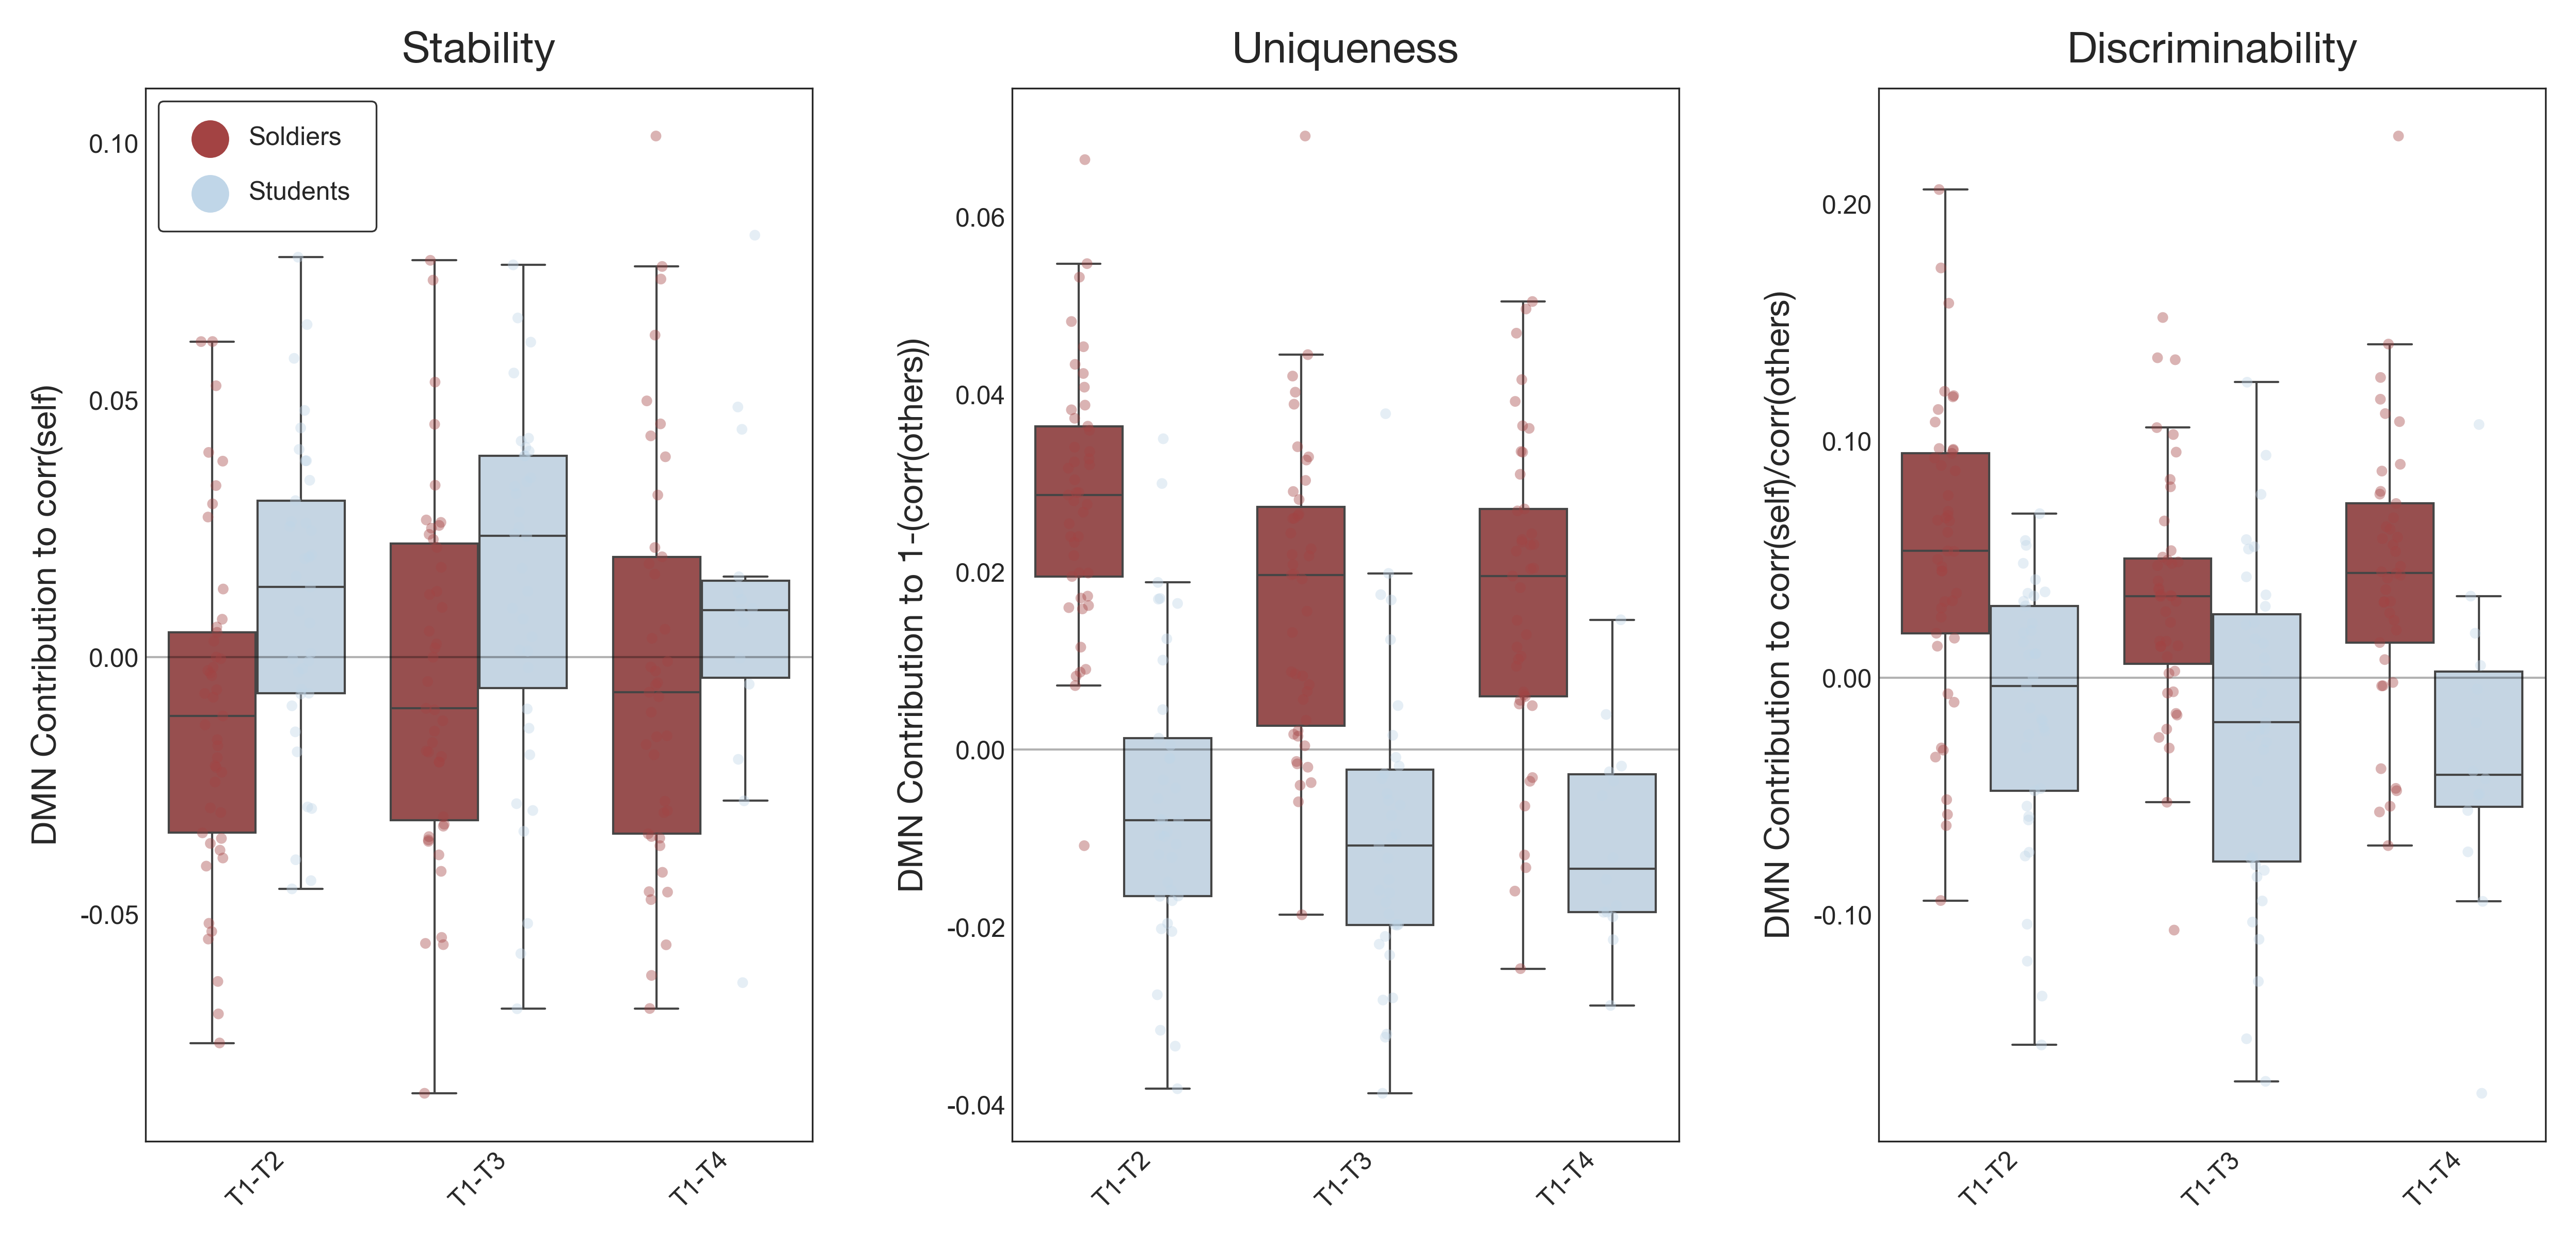

In [100]:
import seaborn as sns
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from matplotlib.ticker import FuncFormatter

# 1. Force white background and no grid
sns.set_style("white")

# Variables of interest and corresponding titles
variables = ["iself", "iothers", "discriminability"]
titles = ["Stability", "Uniqueness", "Discriminability"]
y_labels = ["DMN Contribution to corr(self)", "DMN Contribution to 1-(corr(others))", "DMN Contribution to corr(self)/corr(others)"]

# Create subplots with GridSpec
fig = plt.figure(figsize=(10, 5), dpi=600) # Slightly narrower for tighter look
gs = gridspec.GridSpec(1, len(variables), figure=fig, wspace=0.3)

# Custom palette
custom_palette = ["#A34343", "#C0D6E8"]
sns.set_palette(custom_palette)

# 4 digits for more precision
def format_func(value, tick_number):
    return f'{value:.2f}'

# Iterate over variables and create plots
for i, (var, title, y_label) in enumerate(zip(variables, titles, y_labels)):
    ax = fig.add_subplot(gs[i])
    ax.set_facecolor('white')
    ax.grid(False)
    ax.axhline(0, color='black', linestyle='-', linewidth=0.5, alpha=0.3)
    # Add scatterplot (behind boxplot)
    sns.stripplot(
        x="time", y=var, hue="Group", data=data, 
        dodge=True, jitter=True, alpha=0.4, ax=ax,
        palette=custom_palette, linewidth=0, size=2.5
    )

    # Add boxplot
    sns.boxplot(
        x="time", y=var, hue="Group", data=data, 
        showfliers=False, ax=ax, linewidth=0.5,
        palette=custom_palette
    )

    # Titles
    ax.set_title(title, fontdict={'fontsize': 10, 'fontname': 'Helvetica Neue', 'fontweight': 'bold'})
    
    # Axis Labels
    ax.set_ylabel(y_label, fontdict={'fontsize': 8, 'fontname': 'Helvetica Neue'})
    ax.set_xlabel('')
    
    # FIXED: TICK LABELS - pad=-2 brings the labels closer to the axis
    ax.tick_params(axis='x', rotation=45, labelsize=6, pad=-2)
    ax.tick_params(axis='y', labelsize=6, pad=-2)
    
    ax.yaxis.set_major_formatter(FuncFormatter(format_func))
    ax.locator_params(axis='y', nbins=7)

    # Spines
    for spine in ax.spines.values():
        spine.set_linewidth(0.4)

    # FIXED: LEGEND - Added frame, spacing, and thin border
    if i == 0:
        handles, labels = ax.get_legend_handles_labels()
        labels = [label.replace('Group', '').strip() for label in labels]
        leg = ax.legend(
            handles[:2], labels[:2], 
            title='', 
            frameon=True,         # Added border
            fontsize=6, 
            labelspacing=1.2,     # Less smooshed
            handletextpad=0.5,    # Space between color box and text
            borderpad=1           # Space between text and border
        )
        leg.get_frame().set_linewidth(0.4)
        leg.get_frame().set_edgecolor('black')
    else:
        ax.get_legend().remove()

# Tighten the figure layout
plt.subplots_adjust(bottom=0.2) # Make room for rotated x-labels
plt.show()

In [ ]:
# Network Permutation Testing

In [56]:
def load_all_mats(datadir, subs, length, mat_key=None, dtype=np.float32):
    """
    Loads all subject matrices into array: (n_subs, P, P)
    Returns: mats, subj_ids, used_key
    """
    files = sorted([x for x in os.listdir(datadir) if x[:length] in subs and x.endswith(".mat")])
    if not files:
        raise ValueError(f"No .mat files found in {datadir} for provided subs/length.")

    first = scipy.io.loadmat(os.path.join(datadir, files[0]))
    key = mat_key if mat_key else list(first.keys())[3]
    P = first[key].shape[0]

    mats = np.zeros((len(files), P, P), dtype=dtype)
    subj_ids = []

    for i, f in enumerate(files):
        d = scipy.io.loadmat(os.path.join(datadir, f))
        if key not in d:
            raise KeyError(f"Key '{key}' not found in {f}. Keys: {list(d.keys())[:20]}")
        mats[i] = d[key]
        subj_ids.append(f[:length])

    return mats, subj_ids, key

def align_by_subject_id(mats1, ids1, mats2, ids2):
    """
    Aligns mats1/mats2 so subjects match and order is identical.
    Returns: mats1_aligned, mats2_aligned, common_ids
    """
    common = sorted(set(ids1).intersection(ids2))
    if len(common) < 3:
        raise ValueError(f"Too few matched subjects after alignment: {len(common)}")

    idx1 = [ids1.index(s) for s in common]
    idx2 = [ids2.index(s) for s in common]

    return mats1[idx1], mats2[idx2], common

def sample_disjoint_sets(P, networks, sizes, rng):
    """
    Sample disjoint node sets with given sizes.
    Each node can belong to at most one set in a permutation.
    """
    if sum(sizes) > P:
        raise ValueError(f"Sum of sizes {sum(sizes)} exceeds P={P}.")

    pool = np.arange(P)
    rng.shuffle(pool)

    sets = {}
    start = 0
    for name, k in zip(networks, sizes):
        sets[name] = pool[start:start+k]
        start += k

    return sets


def sr_for_keep_nodes(mats1, mats2, keep_idx):
    """
    mats1/mats2: (n_subs, P, P) aligned
    keep_idx: array of nodes to KEEP
    Returns: success_rate (scalar)
    """
    n_subs = mats1.shape[0]
    k = len(keep_idx)
    if k < 3:
        # too small to be meaningful
        return np.nan

    # precompute lower triangle indices for the kept submatrix
    tril = np.tril_indices(k, k=-1)

    X = np.zeros((k*(k-1)//2, n_subs), dtype=np.float32)
    Y = np.zeros((k*(k-1)//2, n_subs), dtype=np.float32)

    # build edge-vectors per subject (columns) like your original mat2vec output
    for i in range(n_subs):
        m1 = mats1[i][np.ix_(keep_idx, keep_idx)]
        m2 = mats2[i][np.ix_(keep_idx, keep_idx)]
        X[:, i] = m1[tril]
        Y[:, i] = m2[tril]

    sub_cor = create_cor_mat2(X, Y)
    _, sr = calc_success(sub_cor)
    return float(sr)


def contribution_scores_for_sets(mats1, mats2, sets_dict, set_names):
    """
    mats1/mats2 aligned (n_subs, P, P)
    sets_dict[name] = nodes to DROP for that "network"
    set_names: list of 7 names
    """
    K = len(set_names)
    P = mats1.shape[1]
    all_nodes = np.arange(P)

    sr_by_combo = {}

    for r in range(1, K):  # 1..K-1
        for combo in combinations(set_names, r):
            drop_nodes = np.unique(np.concatenate([sets_dict[name] for name in combo]))
            keep_nodes = np.setdiff1d(all_nodes, drop_nodes, assume_unique=False)
            sr_by_combo[combo] = sr_for_keep_nodes(mats1, mats2, keep_nodes)

    C = {}
    for name in set_names:
        with_srs = [sr for combo, sr in sr_by_combo.items() if name in combo]
        without_srs = [sr for combo, sr in sr_by_combo.items() if name not in combo]
        C[name] = float(np.mean(with_srs) - np.mean(without_srs))
    return C


def build_real_nodes(parcel_id, networks):
    real_nodes = {}
    for net in networks:
        idx = parcel_id.loc[parcel_id["Network"] == net, "Parcel_ID"].to_numpy()
        if len(idx) == 0:
            raise ValueError(f"No parcels found for network '{net}'. Check parcel_id['Network'] labels.")
        real_nodes[net] = idx - 1
    return real_nodes


def permute_null_disjoint_size_matched(mats1, mats2, real_nodes, networks, B=200, seed=0, verbose_every=10):
    rng = np.random.default_rng(seed)
    P = mats1.shape[1]
    sizes = [len(real_nodes[n]) for n in networks]

    # sanity
    if sum(sizes) > P:
        raise ValueError("Network sizes sum exceeds P. Cannot sample disjoint sets.")

    null = {n: [] for n in networks}

    for b in range(B):
        pseudo = sample_disjoint_sets(P, networks, sizes, rng)
        Cb = contribution_scores_for_sets(mats1, mats2, pseudo, networks)
        for n in networks:
            null[n].append(Cb[n])

        if verbose_every and (b+1) % verbose_every == 0:
            print(f"Permutation {b+1}/{B} complete.")

    for n in networks:
        null[n] = np.asarray(null[n], dtype=float)
    return null

def pvals_from_null(C_obs, null, two_sided=True):
    p = {}
    for n, obs in C_obs.items():
        dist = null[n]
        B = len(dist)
        if two_sided:
            p[n] = float((1 + np.sum(np.abs(dist) >= abs(obs))) / (1 + B))
        else:
            p[n] = float((1 + np.sum(dist >= obs)) / (1 + B))
    return p

def bh_fdr(pvals_dict):
    names = list(pvals_dict.keys())
    p = np.array([pvals_dict[n] for n in names], dtype=float)
    m = len(p)
    order = np.argsort(p)
    ranked = p[order]
    q = ranked * m / (np.arange(m) + 1)
    q = np.minimum.accumulate(q[::-1])[::-1]
    q = np.clip(q, 0, 1)
    return {names[order[i]]: float(q[i]) for i in range(m)}

In [ ]:
dir_t1='/Volumes/homes/Noga/full_data/Results/Atlas_CMs/T1/' + atlas
dir_t2='/Volumes/homes/Noga/full_data/Results/Atlas_CMs/T2/' + atlas
dir_t3='/Volumes/homes/Noga/full_data/Results/Atlas_CMs/T3/' + atlas
dir_t4='/Volumes/homes/Noga/full_data/Results/Atlas_CMs/T4/' + atlas

dir_t1_con='/Volumes/homes/Noga/full_data/Results/Atlas_CMs/Control/T1/' + atlas
dir_t2_con='/Volumes/homes/Noga/full_data/Results/Atlas_CMs/Control/T2/' + atlas
dir_t3_con='/Volumes/homes/Noga/full_data/Results/Atlas_CMs/Control/T3/' + atlas
dir_t4_con='/Volumes/homes/Noga/full_data/Results/Atlas_CMs/Control/T4/' + atlas

In [ ]:
subs = subs
length = 4
dr1=dir_t1
dr2=dir_t2
networks = ['Vis', 'SomMot', 'DorsAttn', 'SalVentAttn', 'Limbic', 'Cont', 'Default']

# ---- Load + align ----
mats1, ids1, key1 = load_all_mats(dr1, subs, length, mat_key="z_CM_cortex")  # set mat_key if you know it
mats2, ids2, key2 = load_all_mats(dr2, subs, length, mat_key="z_CM_cortex")
mats1, mats2, common_ids = align_by_subject_id(mats1, ids1, mats2, ids2)
print("Aligned N subjects:", len(common_ids), "using key:", key1)

# ---- Real network node sets ----
real_nodes = build_real_nodes(parcel_id, networks)

# ---- Observed contributions ----
print("Computing observed contributions...")
C_obs = contribution_scores_for_sets(mats1, mats2, real_nodes, networks)
print("C_obs:", C_obs)

# ---- Permutation null ----
B = 200  # sanity; increase to 500-2000 for final
print(f"Running disjoint size-matched permutation (B={B})...")
null = permute_null_disjoint_size_matched(mats1, mats2, real_nodes, networks, B=B, seed=0, verbose_every=10)

# ---- p-values + FDR ----
pvals = pvals_from_null(C_obs, null, two_sided=True)
qvals = bh_fdr(pvals)

# ---- Results table ----
df = pd.DataFrame({
    "Network": networks,
    "C_obs": [C_obs[n] for n in networks],
    "p_two_sided": [pvals[n] for n in networks],
    "q_FDR": [qvals[n] for n in networks],
    "null_mean": [null[n].mean() for n in networks],
    "null_sd": [null[n].std(ddof=1) for n in networks],
})
df = df.sort_values("p_two_sided")
print(df)
